# 📊 Sales Prediction Using Machine Learning

## Oasis Infobyte Internship — Data Science Task 5

**Author:** Himanshu Chavda

---

### Project Overview

This project develops a machine learning regression system to predict product sales based on advertising expenditure across three marketing channels:

- TV
- Radio
- Newspaper

The project covers data exploration, visualization, correlation analysis, model training, evaluation, residual analysis, and feature importance.

### Objective

Build and compare machine learning regression models that can predict sales from advertising expenditure and identify which advertising channel has the strongest relationship with sales.

## 1. Problem Statement

Businesses invest in multiple advertising channels to increase product sales. However, understanding the relationship between advertising expenditure and sales can help organizations make better marketing decisions.

This project uses historical advertising data containing spending on TV, Radio, and Newspaper advertising along with the resulting Sales.

The objective is to build a supervised machine learning regression model that learns this relationship and predicts sales for unseen advertising expenditure.

### Problem Type

**Supervised Learning → Regression**

### Input Features

- TV advertising expenditure
- Radio advertising expenditure
- Newspaper advertising expenditure

### Target Variable

- Sales

### Success Criteria

The regression models will be evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

At least two regression models will be compared, and the best-performing model will be selected based on test-set performance.

## 2. Import Libraries

The following libraries are used for data manipulation, numerical computation, visualization, and machine learning.

In [453]:
# ============================================================
# Sales Prediction Using Machine Learning
# Oasis Infobyte - Data Science Task 5
# Author: Himanshu Chavda
# ============================================================

# Data manipulation and numerical computation
import numpy as np
import pandas as pd
from pathlib import Path

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Dataset

The dataset contains advertising expenditure across TV, Radio, and Newspaper channels along with the corresponding product sales.

The dataset is stored locally in the project's `data` directory.

In [454]:
# Load the advertising dataset
data_path = "../data/advertising.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 4. Initial Dataset Inspection

Before performing analysis, we inspect the first few records to understand the structure and values contained in the dataset.

In [455]:
# Display the first five records
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## 5. Data Cleaning

The dataset contains an unnamed index column that does not provide predictive information. It will be removed before model training.

Column names are also standardized to improve consistency throughout the analysis.

In [456]:
# Remove automatically generated index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Standardize column names
df.columns = df.columns.str.strip()

print("Dataset after initial cleaning:")
df.head()

Dataset after initial cleaning:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## 6. Dataset Dimensions

The shape of the dataset indicates the number of observations and variables available for analysis.

In [457]:
# Display dataset dimensions
rows, columns = df.shape

print(f"Number of rows    : {rows}")
print(f"Number of columns : {columns}")

Number of rows    : 200
Number of columns : 4


## 7. Dataset Information

The `info()` method provides information about the columns, data types, and non-null observations.

In [458]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


### Data Types

Checking data types ensures that numerical features are correctly represented as numeric values before statistical analysis and model training.

In [459]:
# Display data types
df.dtypes

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

## 8. Missing Value Analysis

Missing values can affect statistical analysis and machine learning models. Therefore, the dataset is checked for missing observations before proceeding.

In [460]:
# Count missing values in each column
missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

print(f"\nTotal missing values: {missing_values.sum()}")

Missing values by column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Total missing values: 0


### Duplicate Records

Duplicate records can introduce bias into analysis and model training. The dataset is checked for duplicate rows.

In [461]:
# Check duplicate records
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [462]:
# Remove duplicate records if any exist
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicate records removed.")
else:
    print("No duplicate records found.")

No duplicate records found.


## 9. Descriptive Statistics

Descriptive statistics provide a numerical summary of the dataset, including:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

These statistics help us understand the scale and distribution of each variable.

In [463]:
# Generate descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


## 10. Key Dataset Statistics

A few important statistics are calculated to understand advertising expenditure and sales performance.

In [464]:
# Calculate important summary statistics
summary = pd.DataFrame({
    "Metric": [
        "Average TV Spend",
        "Average Radio Spend",
        "Average Newspaper Spend",
        "Average Sales",
        "Maximum Sales",
        "Minimum Sales"
    ],
    "Value": [
        df["TV"].mean(),
        df["Radio"].mean(),
        df["Newspaper"].mean(),
        df["Sales"].mean(),
        df["Sales"].max(),
        df["Sales"].min()
    ]
})

summary

,Metric,Value
0,Average TV Spend,147.0425
1,Average Radio Spend,23.2640
2,Average Newspaper Spend,30.5540
3,Average Sales,14.0225
4,Maximum Sales,27.0000
5,Minimum Sales,1.6000


# Visualization Theme

A consistent professional visualization theme is applied throughout the
Sales Prediction analysis to improve readability, maintain visual
consistency, and create a portfolio-ready Data Science project.

The visualization design uses a modern dark theme with carefully selected
colors to highlight relationships between advertising expenditure and
product sales.

The visualization theme will be used for:

- Exploratory Data Analysis (EDA)
- Pairplot visualization
- Feature relationship analysis
- Correlation heatmap
- Scatter plots
- Model evaluation charts
- Residual analysis
- Feature importance visualization

Using a consistent visual identity makes the notebook easier to
understand while presenting the analysis in a clean, professional,
and industry-standard format.

In [465]:
# ============================================================
# CREATE OUTPUT DIRECTORY
# ============================================================

IMAGES_DIR = Path("../images")
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Images directory ready.")
print(f"📁 Location : {IMAGES_DIR.resolve()}")

✅ Images directory ready.
📁 Location : C:\Users\USER\PycharmProjects\OIBSIP\OIBSIP\DataScience-Task5-SalesPrediction\images


In [466]:
# ============================================================
# PROFESSIONAL VISUALIZATION THEME
# ============================================================

sns.set_theme(
    style="darkgrid",
    context="notebook"
)

plt.rcParams.update({

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,

    # --------------------------------------------------------
    # Background
    # --------------------------------------------------------

    "figure.facecolor": "#0F172A",
    "axes.facecolor": "#111827",

    # --------------------------------------------------------
    # Text
    # --------------------------------------------------------

    "text.color": "#F8FAFC",
    "axes.labelcolor": "#E2E8F0",
    "axes.titlecolor": "#F8FAFC",

    # --------------------------------------------------------
    # Titles
    # --------------------------------------------------------

    "axes.titleweight": "bold",
    "axes.titlesize": 18,

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    "axes.labelsize": 12,

    # --------------------------------------------------------
    # Tick Labels
    # --------------------------------------------------------

    "xtick.color": "#CBD5E1",
    "ytick.color": "#CBD5E1",

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # --------------------------------------------------------
    # Axis Border
    # --------------------------------------------------------

    "axes.edgecolor": "#334155",

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    "grid.color": "#334155",
    "grid.alpha": 0.30,
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,

    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    "legend.fontsize": 10,

    # --------------------------------------------------------
    # Saving
    # --------------------------------------------------------

    "savefig.facecolor": "#0F172A",
    "savefig.edgecolor": "#0F172A"

})

print("✅ Professional visualization environment configured successfully.")

✅ Professional visualization environment configured successfully.


In [467]:
# ============================================================
# SALES PREDICTION COLOR PALETTE
# ============================================================

SALES_COLORS = {

    # --------------------------------------------------------
    # Primary
    # --------------------------------------------------------

    "primary": "#38BDF8",
    "secondary": "#8B5CF6",

    # --------------------------------------------------------
    # Advertising Channels
    # --------------------------------------------------------

    "tv": "#3B82F6",
    "radio": "#F97316",
    "newspaper": "#22C55E",

    # --------------------------------------------------------
    # Target Variable
    # --------------------------------------------------------

    "sales": "#EAB308",

    # --------------------------------------------------------
    # Model Colors
    # --------------------------------------------------------

    "linear_regression": "#38BDF8",
    "random_forest": "#8B5CF6",

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    "best": "#22C55E",
    "average": "#F59E0B",
    "poor": "#EF4444",

    # --------------------------------------------------------
    # Text
    # --------------------------------------------------------

    "text": "#F8FAFC",
    "muted": "#94A3B8",

    # --------------------------------------------------------
    # Background
    # --------------------------------------------------------

    "background": "#0F172A",
    "axes": "#111827",

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    "grid": "#334155"

}

print("🎨 Sales Prediction color palette loaded successfully.")

print("\nAdvertising Channels")
print(f"TV         : {SALES_COLORS['tv']}")
print(f"Radio      : {SALES_COLORS['radio']}")
print(f"Newspaper  : {SALES_COLORS['newspaper']}")
print(f"Sales      : {SALES_COLORS['sales']}")

🎨 Sales Prediction color palette loaded successfully.

Advertising Channels
TV         : #3B82F6
Radio      : #F97316
Newspaper  : #22C55E
Sales      : #EAB308


In [468]:
# ============================================================
# REUSABLE CHART FORMATTING FUNCTION
# ============================================================

def format_chart(
    title,
    xlabel=None,
    ylabel=None,
    grid_axis="both"
):

    ax = plt.gca()

    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------

    ax.set_title(
        title,
        fontsize=18,
        fontweight="bold",
        color=SALES_COLORS["text"],
        pad=18
    )

    # --------------------------------------------------------
    # X Label
    # --------------------------------------------------------

    if xlabel:

        ax.set_xlabel(
            xlabel,
            fontsize=12,
            color=SALES_COLORS["text"],
            labelpad=10
        )

    # --------------------------------------------------------
    # Y Label
    # --------------------------------------------------------

    if ylabel:

        ax.set_ylabel(
            ylabel,
            fontsize=12,
            color=SALES_COLORS["text"],
            labelpad=10
        )

    # --------------------------------------------------------
    # Tick Style
    # --------------------------------------------------------

    ax.tick_params(
        axis="both",
        colors=SALES_COLORS["muted"],
        labelsize=10
    )

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    if grid_axis != "none":

        ax.grid(
            True,
            axis=grid_axis,
            linestyle="--",
            linewidth=0.7,
            alpha=0.30,
            color=SALES_COLORS["grid"]
        )

    else:

        ax.grid(False)

    # --------------------------------------------------------
    # Border
    # --------------------------------------------------------

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color(
        SALES_COLORS["grid"]
    )

    ax.spines["bottom"].set_color(
        SALES_COLORS["grid"]
    )

    plt.tight_layout()

print("📊 Professional chart formatter created successfully.")
print("✅ Visualization environment ready for Sales Prediction.")

📊 Professional chart formatter created successfully.
✅ Visualization environment ready for Sales Prediction.


## 11. Exploratory Data Analysis

### Pairplot

A pairplot provides a visual overview of relationships between all numerical variables.

It helps identify:

- Positive or negative relationships
- Potential linear relationships
- Feature distributions
- Possible outliers
- Relationships between advertising channels and sales

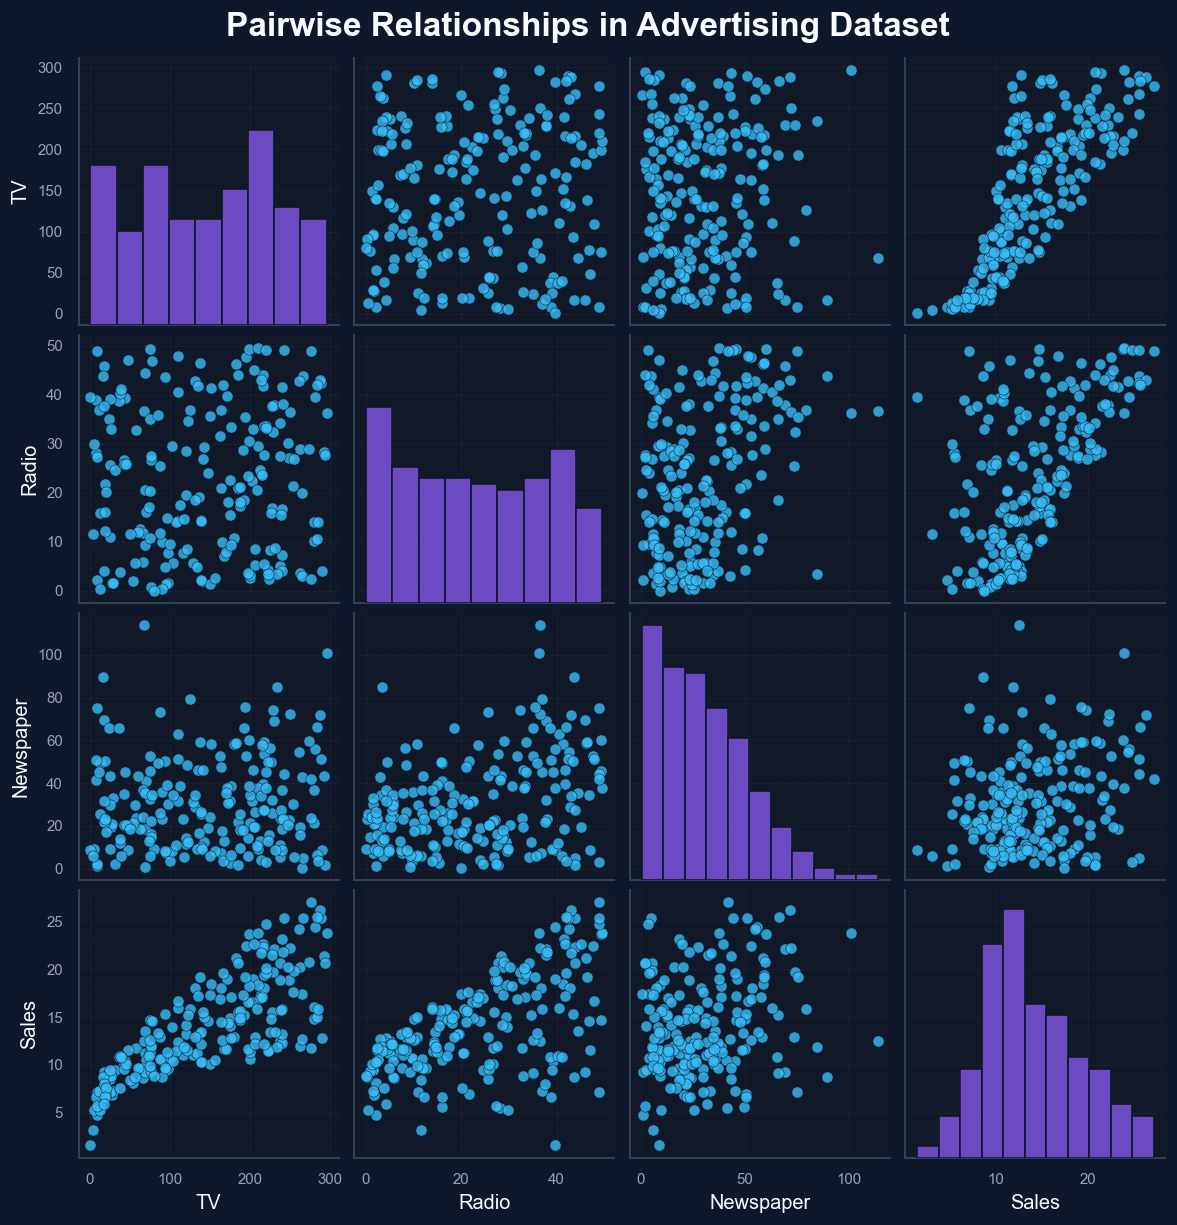

✅ Pairplot created successfully.
💾 Saved as : images/pairplot_relationships.png


In [469]:
# ============================================================
# PAIRPLOT OF ADVERTISING DATASET
# ============================================================

pairplot = sns.pairplot(
    df,
    diag_kind="hist",
    corner=False,
    plot_kws={
        "color": SALES_COLORS["primary"],
        "alpha": 0.80,
        "s": 45,
        "edgecolor": SALES_COLORS["background"],
        "linewidth": 0.4
    },
    diag_kws={
        "color": SALES_COLORS["secondary"],
        "edgecolor": SALES_COLORS["background"]
    }
)

# ------------------------------------------------------------
# Figure Title
# ------------------------------------------------------------

pairplot.fig.suptitle(
    "Pairwise Relationships in Advertising Dataset",
    fontsize=20,
    fontweight="bold",
    color=SALES_COLORS["text"],
    y=1.02
)

# ------------------------------------------------------------
# Apply Theme to Every Axis
# ------------------------------------------------------------

for ax in pairplot.axes.flatten():

    if ax is None:
        continue

    ax.set_facecolor(SALES_COLORS["axes"])

    ax.tick_params(
        colors=SALES_COLORS["muted"],
        labelsize=9
    )

    ax.xaxis.label.set_color(SALES_COLORS["text"])
    ax.yaxis.label.set_color(SALES_COLORS["text"])

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.6,
        alpha=0.30,
        color=SALES_COLORS["grid"]
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color(SALES_COLORS["grid"])
    ax.spines["bottom"].set_color(SALES_COLORS["grid"])

# ------------------------------------------------------------
# Save Figure
# ------------------------------------------------------------

pairplot.fig.savefig(
    IMAGES_DIR / "pairplot_relationships.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=SALES_COLORS["background"]
)

plt.show()

print("✅ Pairplot created successfully.")
print("💾 Saved as : images/pairplot_relationships.png")

In [470]:
# ============================================================
# KEY OBSERVATIONS FROM PAIRPLOT
# ============================================================

FEATURES = ["TV", "Radio", "Newspaper"]
TARGET = "Sales"

# ------------------------------------------------------------
# Calculate Correlations with Sales
# ------------------------------------------------------------

sales_correlations = (
    df[FEATURES + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(ascending=False)
)

# ------------------------------------------------------------
# Identify Strongest Positive Relationship
# ------------------------------------------------------------

strongest_feature = sales_correlations.idxmax()
strongest_correlation = sales_correlations.max()

# ------------------------------------------------------------
# Identify Weakest Relationship
# ------------------------------------------------------------

weakest_feature = sales_correlations.abs().idxmin()
weakest_correlation = sales_correlations[weakest_feature]

# ------------------------------------------------------------
# Display Key Observations
# ------------------------------------------------------------

print("🔍 KEY OBSERVATIONS")
print("=" * 60)

print(
    "\n• The pairplot provides an overall view of the relationships "
    "between advertising channels and Sales."
)

print(
    f"\n• {strongest_feature} advertising shows the strongest "
    f"positive relationship with Sales "
    f"(correlation: {strongest_correlation:.2f})."
)

print(
    f"\n• {weakest_feature} advertising shows the weakest "
    f"relationship with Sales "
    f"(correlation: {weakest_correlation:.2f})."
)

print(
    "\n• Radio advertising also shows a positive association "
    "with Sales, although it is weaker than the strongest channel."
)

print(
    "\n• The distributions and pairwise relationships will help "
    "guide feature selection and model development."
)

print("\n" + "=" * 60)
print("✅ Pairplot observations generated successfully.")

🔍 KEY OBSERVATIONS

• The pairplot provides an overall view of the relationships between advertising channels and Sales.

• TV advertising shows the strongest positive relationship with Sales (correlation: 0.78).

• Newspaper advertising shows the weakest relationship with Sales (correlation: 0.23).

• Radio advertising also shows a positive association with Sales, although it is weaker than the strongest channel.

• The distributions and pairwise relationships will help guide feature selection and model development.

✅ Pairplot observations generated successfully.


### 🔍 Key Observations

- The pairplot provides a complete overview of the relationships between all advertising channels and product sales.
- **TV advertising** shows the strongest positive relationship with **Sales**, indicating that it is likely to be the most influential predictive feature.
- **Radio advertising** also shows a positive association with Sales, although the relationship is comparatively weaker.
- **Newspaper advertising** demonstrates a relatively weak association with Sales.
- The feature distributions and pairwise relationships provide useful insights for feature selection and model development.

## 12. TV Advertising vs Sales

This scatter plot examines whether increased TV advertising expenditure is associated with changes in product sales.

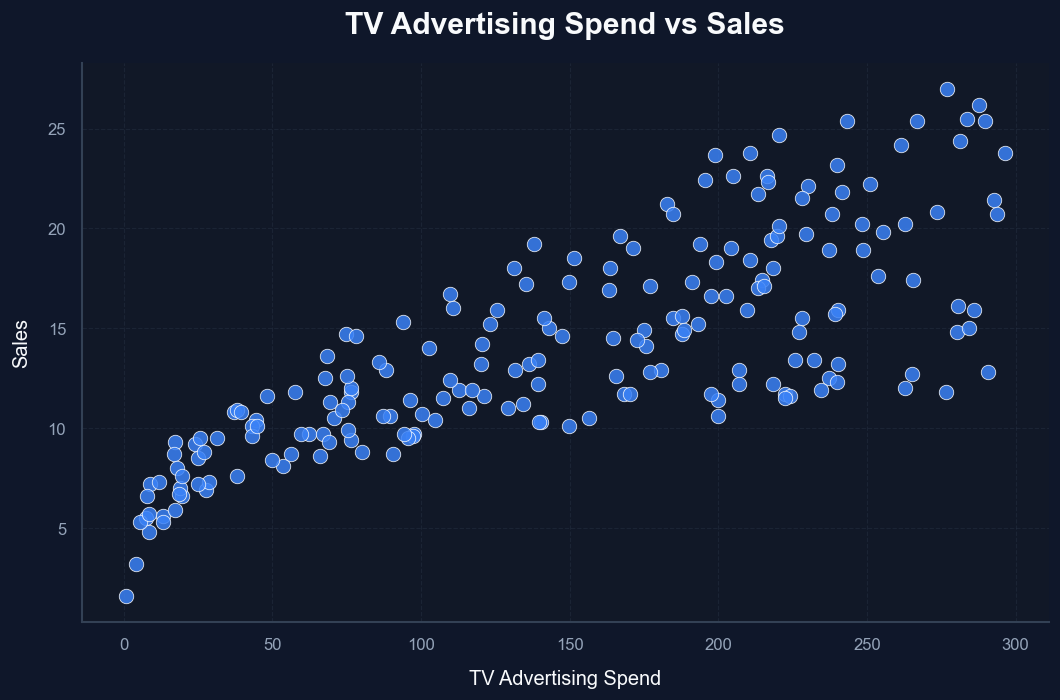

✅ TV vs Sales scatter plot created successfully.
💾 Chart saved as: images/tv_advertising_vs_sales.png


In [471]:
# ============================================================
# TV ADVERTISING SPEND VS SALES
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="TV",
    y="Sales",
    color=SALES_COLORS["tv"],
    s=75,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5
)

# ------------------------------------------------------------
# Chart Formatting
# ------------------------------------------------------------

format_chart(
    title="TV Advertising Spend vs Sales",
    xlabel="TV Advertising Spend",
    ylabel="Sales"
)

# ------------------------------------------------------------
# Save Chart
# ------------------------------------------------------------

plt.savefig(
    IMAGES_DIR / "tv_advertising_vs_sales.png",
    bbox_inches="tight"
)

plt.show()

print("✅ TV vs Sales scatter plot created successfully.")
print("💾 Chart saved as: images/tv_advertising_vs_sales.png")

## 🔎 Key Observation

The scatter plot shows a clear positive relationship between TV advertising
spend and sales. As TV advertising expenditure increases, sales generally
tend to increase, indicating that TV is an important predictor of sales
in this dataset.

## 13. Radio Advertising vs Sales

This visualization examines the relationship between Radio advertising expenditure and product sales.

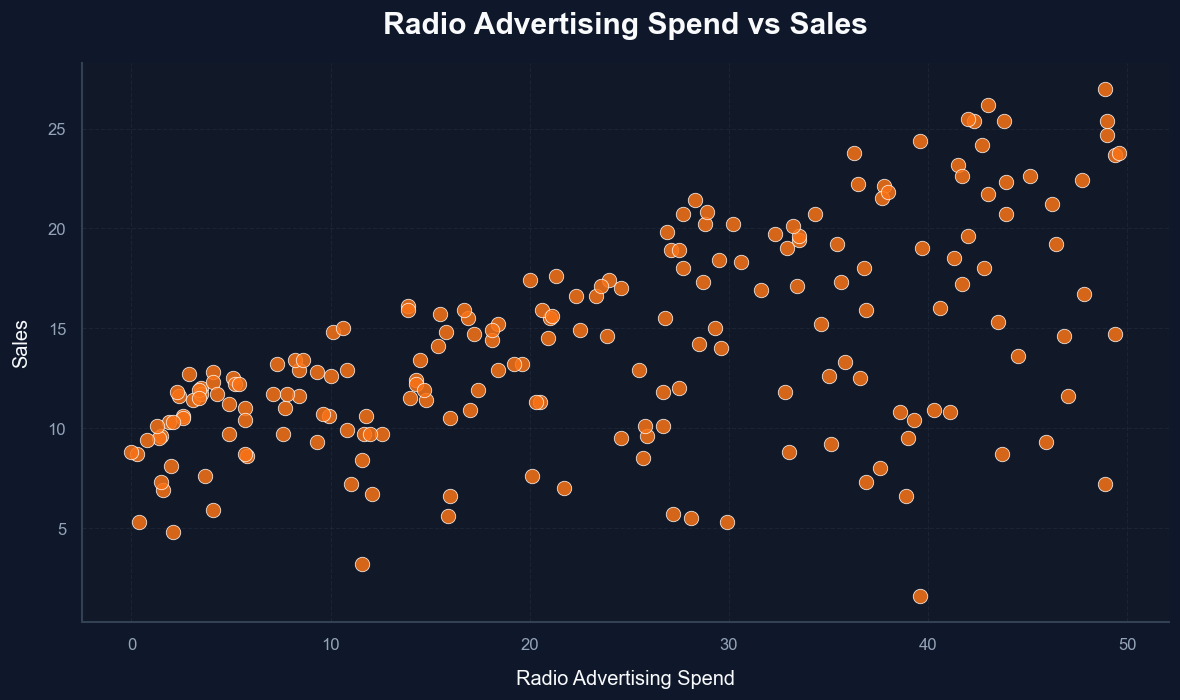

✅ Radio vs Sales visualization created successfully.
💾 Saved to: ..\images\radio_vs_sales.png


In [472]:
# ============================================================
# RADIO ADVERTISING SPEND VS SALES
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Radio",
    y="Sales",
    color=SALES_COLORS["radio"],
    s=75,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5
)

# ------------------------------------------------------------
# Chart Formatting
# ------------------------------------------------------------

format_chart(
    title="Radio Advertising Spend vs Sales",
    xlabel="Radio Advertising Spend",
    ylabel="Sales"
)

# ------------------------------------------------------------
# Save Visualization
# ------------------------------------------------------------

plt.savefig(
    IMAGES_DIR / "radio_vs_sales.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

print("✅ Radio vs Sales visualization created successfully.")
print(f"💾 Saved to: {IMAGES_DIR / 'radio_vs_sales.png'}")

## 🔎 Key Observation

The scatter plot shows a clear positive relationship between Radio advertising expenditure and Sales. As Radio advertising spend increases, Sales generally tend to increase, indicating that Radio is an important predictor of product Sales.

## 14. Newspaper Advertising vs Sales

This scatter plot examines the relationship between Newspaper advertising expenditure and product sales.

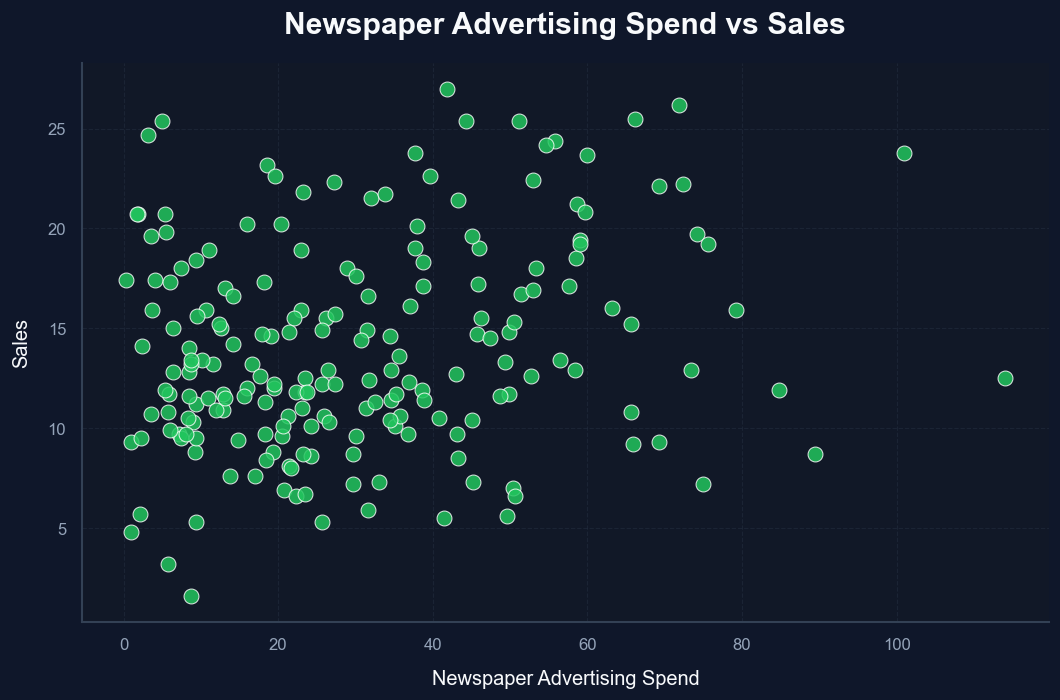

✅ Newspaper vs Sales visualization created successfully.
💾 Image saved to: ..\images\newspaper_vs_sales.png


In [473]:
# ============================================================
# NEWSPAPER ADVERTISING SPEND VS SALES
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Newspaper",
    y="Sales",
    color=SALES_COLORS["newspaper"],
    s=80,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.6
)

format_chart(
    title="Newspaper Advertising Spend vs Sales",
    xlabel="Newspaper Advertising Spend",
    ylabel="Sales"
)

plt.savefig(
    IMAGES_DIR / "newspaper_vs_sales.png",
    bbox_inches="tight"
)

plt.show()

print("✅ Newspaper vs Sales visualization created successfully.")
print(f"💾 Image saved to: {IMAGES_DIR / 'newspaper_vs_sales.png'}")

## 🔎 Key Observation

The scatter plot shows the relationship between newspaper advertising
expenditure and product sales. The points indicate how changes in
newspaper spending are associated with changes in sales.

Compared with the other advertising channels, the relationship appears
weaker, suggesting that newspaper advertising may have a lower predictive
influence on sales.

## 15. Correlation Analysis

Correlation measures the strength and direction of the linear relationship between numerical variables.

The correlation coefficient ranges from:

- `+1` → strong positive relationship
- `0` → no linear relationship
- `-1` → strong negative relationship

Correlation will be used as an exploratory tool to understand how advertising channels are associated with Sales.

,TV,Radio,Newspaper,Sales
TV,1.00,0.05,0.06,0.78
Radio,0.05,1.00,0.35,0.58
Newspaper,0.06,0.35,1.00,0.23
Sales,0.78,0.58,0.23,1.00


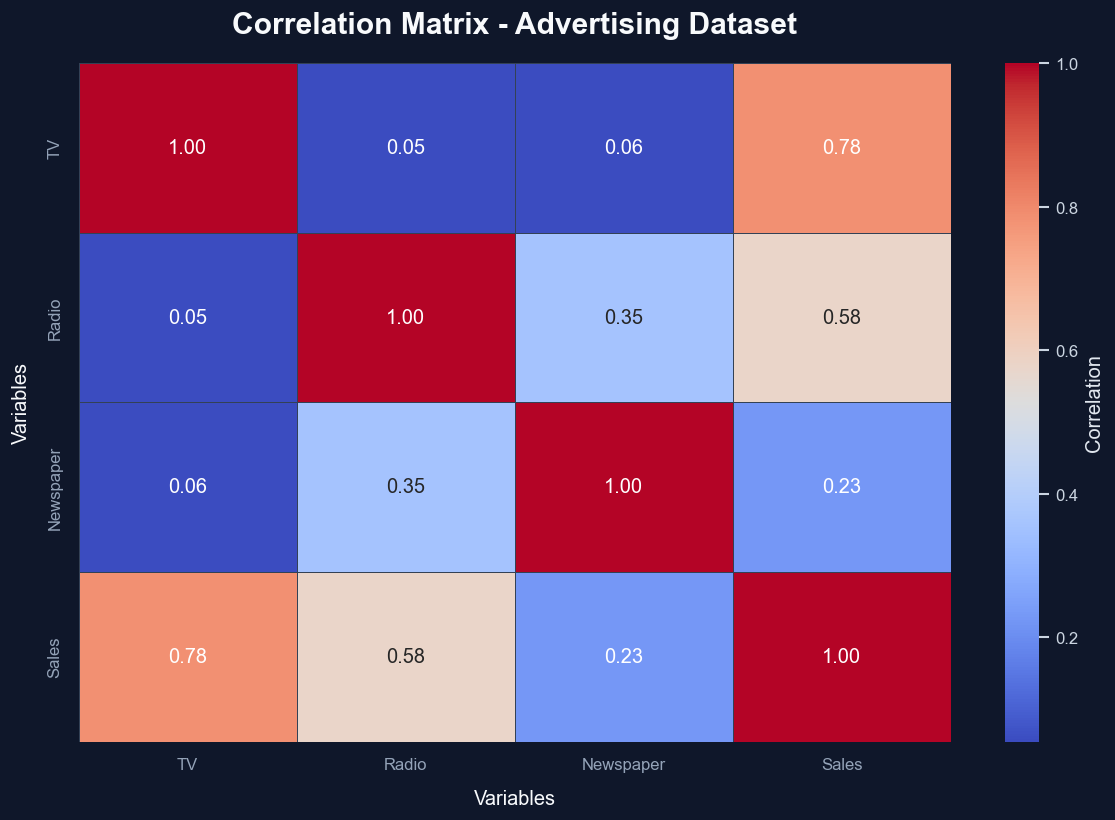

✅ Correlation heatmap created successfully.
💾 Image saved: images/correlation_heatmap.png


In [474]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

# Calculate correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Display correlation matrix
display(
    correlation_matrix.style.format("{:.2f}")
)

# Create figure
plt.figure(figsize=(10, 7))

# Create heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor=SALES_COLORS["grid"],
    cbar_kws={
        "label": "Correlation"
    }
)

# Apply professional chart formatting
format_chart(
    title="Correlation Matrix - Advertising Dataset",
    xlabel="Variables",
    ylabel="Variables",
    grid_axis="none"
)

# Save visualization
plt.savefig(
    IMAGES_DIR / "correlation_heatmap.png",
    bbox_inches="tight",
    facecolor=SALES_COLORS["background"]
)

# Display chart
plt.show()

print("✅ Correlation heatmap created successfully.")
print("💾 Image saved: images/correlation_heatmap.png")

## 🔎 Key Observation

The correlation analysis shows that **TV advertising has the strongest
positive linear relationship with Sales**, while Radio also shows a
positive relationship. Newspaper advertising has a comparatively weaker
relationship with Sales.

These correlations indicate association between advertising expenditure
and Sales, but they do not by themselves establish causation.

## 16. Feature Selection

The target variable is `Sales`.

The following advertising expenditure variables will be used as input features:

- TV
- Radio
- Newspaper

### Features

`X = [TV, Radio, Newspaper]`

### Target

`y = Sales`

In [475]:
# Define features and target
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Feature columns:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.name)

Feature columns:
['TV', 'Radio', 'Newspaper']

Target column:
Sales


## 17. Train-Test Split

The dataset is divided into training and testing subsets.

- **80%** of the data is used to train the models.
- **20%** is reserved for evaluating model performance on unseen data.

A fixed `random_state` is used to make the experiment reproducible.

In [476]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Training samples: 160
Testing samples : 40


## 18. Model 1 — Linear Regression

Linear Regression is used as the baseline regression model.

The model attempts to learn a linear relationship between advertising expenditure and sales.

The general form is:

**Sales = β₀ + β₁(TV) + β₂(Radio) + β₃(Newspaper)**

Where:

- β₀ is the intercept.
- β₁, β₂, and β₃ are feature coefficients.

Linear Regression is useful as a baseline because its coefficients are easy to interpret.

In [477]:
# Initialize Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [478]:
# Generate predictions on the test set
linear_predictions = linear_model.predict(X_test)

print("First 10 Linear Regression predictions:")
print(linear_predictions[:10])

First 10 Linear Regression predictions:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


## 19. Model 2 — Random Forest Regressor

Random Forest Regressor is an ensemble machine learning algorithm that combines multiple decision trees to produce predictions.

Unlike Linear Regression, Random Forest can model nonlinear relationships between features and the target.

It is used as the second model so that its performance can be compared with the simpler Linear Regression baseline.

In [479]:
# Initialize Random Forest Regressor
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest Regressor trained successfully.")

Random Forest Regressor trained successfully.


In [480]:
# Generate predictions on the test set
random_forest_predictions = random_forest_model.predict(X_test)

print("First 10 Random Forest predictions:")
print(random_forest_predictions[:10])

First 10 Random Forest predictions:
[17.732      21.73766667 20.868       6.82133333 23.099      13.46933333
 22.49866667  9.66966667 11.84566667 15.547     ]


## 20. Model Evaluation

The models will be evaluated using three regression metrics:

### Mean Absolute Error (MAE)

Measures the average absolute difference between actual and predicted values.

Lower is better.

### Root Mean Squared Error (RMSE)

Measures prediction error while giving greater weight to larger errors.

Lower is better.

### R² Score

Measures the proportion of variance in the target that is explained by the model.

Higher is better, with a theoretical maximum of 1.0.

In [481]:
def evaluate_regression_model(model_name, y_true, y_pred):
    """
    Calculate standard regression evaluation metrics.

    Parameters
    ----------
    model_name : str
        Name of the model.
    y_true : pandas.Series
        Actual target values.
    y_pred : array-like
        Predicted target values.

    Returns
    -------
    dict
        Model name and evaluation metrics.
    """

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    }

In [482]:
# Evaluate both models
linear_results = evaluate_regression_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

random_forest_results = evaluate_regression_model(
    "Random Forest",
    y_test,
    random_forest_predictions
)

# Create model comparison table
results_df = pd.DataFrame([
    linear_results,
    random_forest_results
])

results_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.613075,0.740335,0.982635


In [483]:
# Identify the best model based on the highest R² score
best_model_row = results_df.loc[
    results_df["R² Score"].idxmax()
]

best_model_name = best_model_row["Model"]

print(f"Best-performing model: {best_model_name}")
print(f"R² Score: {best_model_row['R² Score']:.4f}")
print(f"MAE: {best_model_row['MAE']:.4f}")
print(f"RMSE: {best_model_row['RMSE']:.4f}")

Best-performing model: Random Forest
R² Score: 0.9826
MAE: 0.6131
RMSE: 0.7403


## 21. Actual vs Predicted Sales

This visualization compares the actual sales values with the predictions produced by the best-performing model.

Predictions closer to the diagonal reference line indicate better agreement between actual and predicted values.

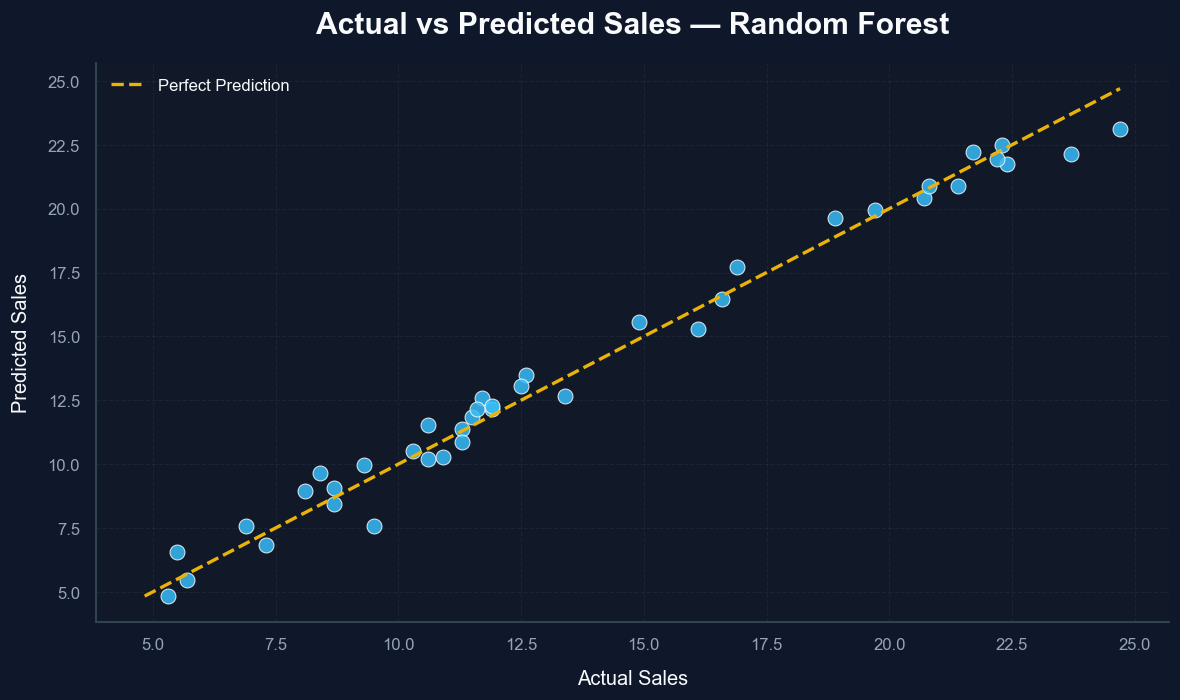

✅ Actual vs Predicted Sales chart created successfully.
📁 Saved to: C:\Users\USER\PycharmProjects\OIBSIP\OIBSIP\DataScience-Task5-SalesPrediction\images\actual_vs_predicted_sales.png


In [484]:
# ============================================================
# ACTUAL VS PREDICTED SALES
# ============================================================

# ------------------------------------------------------------
# Select predictions from the best-performing model
# ------------------------------------------------------------

if best_model_name == "Linear Regression":
    best_predictions = linear_predictions

else:
    best_predictions = random_forest_predictions


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))


# ------------------------------------------------------------
# Actual vs Predicted scatter plot
# ------------------------------------------------------------

sns.scatterplot(
    x=y_test,
    y=best_predictions,
    s=80,
    color=SALES_COLORS["primary"],
    edgecolor="white",
    linewidth=0.6,
    alpha=0.85
)


# ------------------------------------------------------------
# Perfect prediction reference line
# ------------------------------------------------------------

min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color=SALES_COLORS["sales"],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)


# ------------------------------------------------------------
# Apply professional chart formatting
# ------------------------------------------------------------

format_chart(
    title=f"Actual vs Predicted Sales — {best_model_name}",
    xlabel="Actual Sales",
    ylabel="Predicted Sales",
    grid_axis="both"
)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

plt.legend(
    frameon=False,
    labelcolor=SALES_COLORS["text"]
)


# ------------------------------------------------------------
# Save visualization
# ------------------------------------------------------------

actual_predicted_path = IMAGES_DIR / "actual_vs_predicted_sales.png"

plt.savefig(
    actual_predicted_path,
    bbox_inches="tight",
    facecolor=SALES_COLORS["background"]
)


# ------------------------------------------------------------
# Display visualization
# ------------------------------------------------------------

plt.show()

print("✅ Actual vs Predicted Sales chart created successfully.")
print(f"📁 Saved to: {actual_predicted_path.resolve()}")

## 🔍 Key Observation

The predictions are generally aligned with the actual sales values,
with points positioned close to the perfect-prediction reference line.

This indicates that the selected model is able to capture the
relationship between advertising expenditure and product sales
with relatively good prediction accuracy.

## 22. Residual Analysis

A residual is the difference between the actual target value and the predicted value.

**Residual = Actual − Predicted**

A good regression model should generally produce residuals that are:

- Centered around zero
- Relatively randomly distributed
- Free from obvious systematic patterns

A visible pattern in the residual plot may indicate that the model is not capturing some structure in the data.

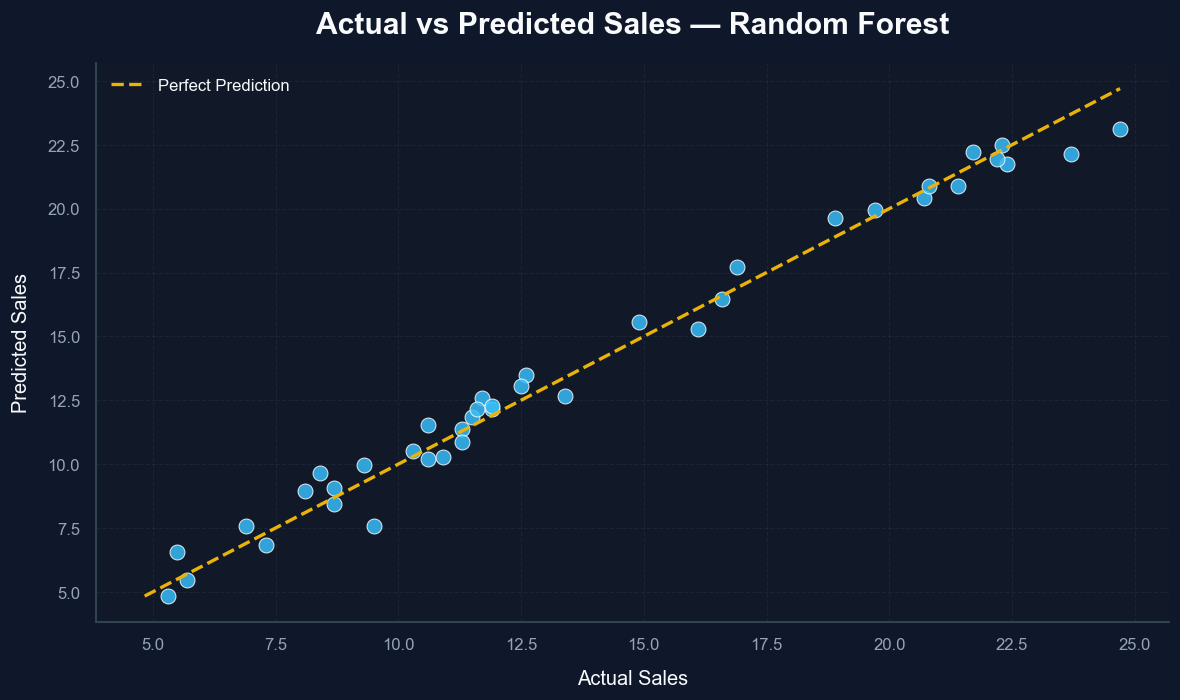

✅ Actual vs Predicted Sales chart created successfully.
📁 Saved to: C:\Users\USER\PycharmProjects\OIBSIP\OIBSIP\DataScience-Task5-SalesPrediction\images\actual_vs_predicted_sales.png


In [485]:
# ============================================================
# ACTUAL VS PREDICTED SALES
# ============================================================

# ------------------------------------------------------------
# Select predictions from the best-performing model
# ------------------------------------------------------------

if best_model_name == "Linear Regression":
    best_predictions = linear_predictions
else:
    best_predictions = random_forest_predictions


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))


# ------------------------------------------------------------
# Actual vs Predicted scatter plot
# ------------------------------------------------------------

sns.scatterplot(
    x=y_test,
    y=best_predictions,
    s=80,
    color=SALES_COLORS["primary"],
    edgecolor="white",
    linewidth=0.6,
    alpha=0.85
)


# ------------------------------------------------------------
# Perfect prediction reference line
# ------------------------------------------------------------

min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color=SALES_COLORS["sales"],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)


# ------------------------------------------------------------
# Apply professional chart formatting
# ------------------------------------------------------------

format_chart(
    title=f"Actual vs Predicted Sales — {best_model_name}",
    xlabel="Actual Sales",
    ylabel="Predicted Sales",
    grid_axis="both"
)


# ------------------------------------------------------------
# Add legend
# ------------------------------------------------------------

plt.legend(
    frameon=False,
    labelcolor=SALES_COLORS["text"]
)


# ------------------------------------------------------------
# Save visualization
# ------------------------------------------------------------

actual_predicted_path = (
    IMAGES_DIR / "actual_vs_predicted_sales.png"
)

plt.savefig(
    actual_predicted_path,
    bbox_inches="tight",
    facecolor=SALES_COLORS["background"]
)


# ------------------------------------------------------------
# Display visualization
# ------------------------------------------------------------

plt.show()


# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------

print("✅ Actual vs Predicted Sales chart created successfully.")
print(f"📁 Saved to: {actual_predicted_path.resolve()}")

## 🔍 Key Observation

The Actual vs Predicted Sales plot shows how closely the model's
predictions match the observed sales values.

Points closer to the perfect prediction line indicate more accurate
predictions, while larger deviations represent higher prediction errors.
Overall, the plot provides a visual assessment of the model's predictive
performance.

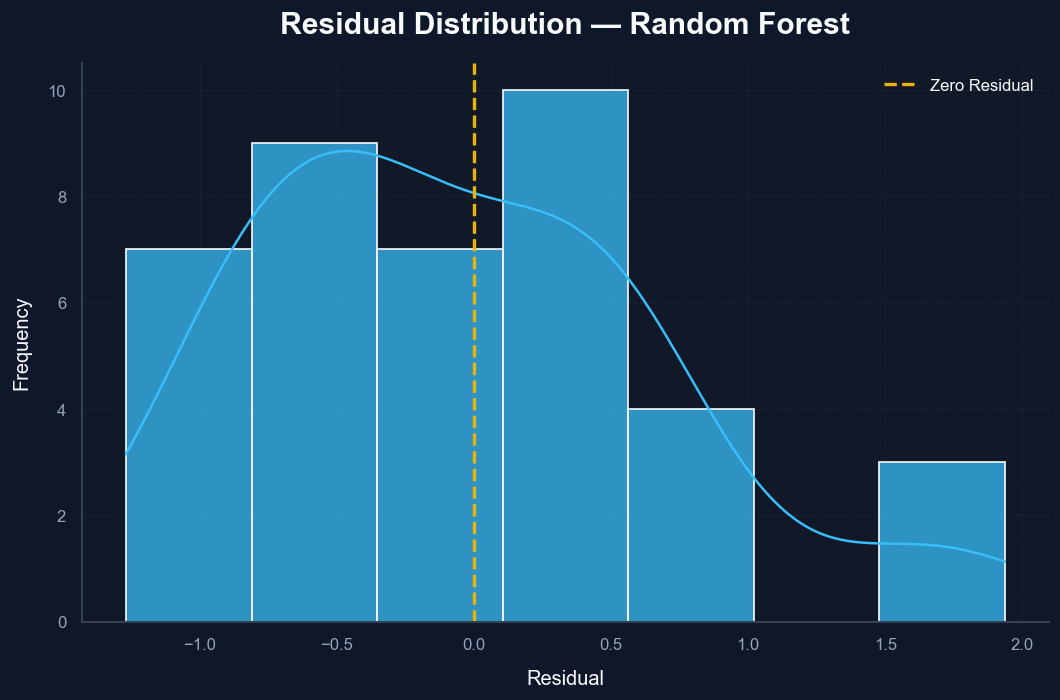

✅ Residual distribution chart created successfully.
📁 Saved to: ..\images\residual_distribution.png


In [486]:
# ============================================================
# RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

sns.histplot(
    residuals,
    kde=True,
    color=SALES_COLORS["primary"],
    edgecolor=SALES_COLORS["text"],
    alpha=0.75
)

# ------------------------------------------------------------
# Zero Reference Line
# ------------------------------------------------------------

plt.axvline(
    x=0,
    color=SALES_COLORS["sales"],
    linestyle="--",
    linewidth=2,
    label="Zero Residual"
)

# ------------------------------------------------------------
# Chart Formatting
# ------------------------------------------------------------

format_chart(
    title=f"Residual Distribution — {best_model_name}",
    xlabel="Residual",
    ylabel="Frequency",
    grid_axis="y"
)

plt.legend(
    frameon=False,
    labelcolor=SALES_COLORS["text"]
)

# ------------------------------------------------------------
# Save Figure
# ------------------------------------------------------------

plt.savefig(
    IMAGES_DIR / "residual_distribution.png",
    bbox_inches="tight",
    facecolor=SALES_COLORS["background"]
)

plt.show()

print("✅ Residual distribution chart created successfully.")
print(f"📁 Saved to: {IMAGES_DIR / 'residual_distribution.png'}")

## 🔎 Key Observation

The residual distribution is centered around zero, indicating that the
model errors are generally balanced between over-prediction and
under-prediction.

A relatively concentrated distribution around zero suggests that the
model is producing reasonably consistent prediction errors without a
strong systematic bias.

## 23. Advertising Channel Impact — Linear Regression

Linear Regression coefficients indicate how the predicted Sales value changes with a one-unit increase in a feature while keeping the other features constant.

The coefficients provide an interpretable way to compare the estimated linear contribution of TV, Radio, and Newspaper advertising.

In [487]:
# Extract Linear Regression coefficients
coefficient_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

coefficient_df

,Feature,Coefficient
1,Radio,0.189195
0,TV,0.044730
2,Newspaper,0.002761


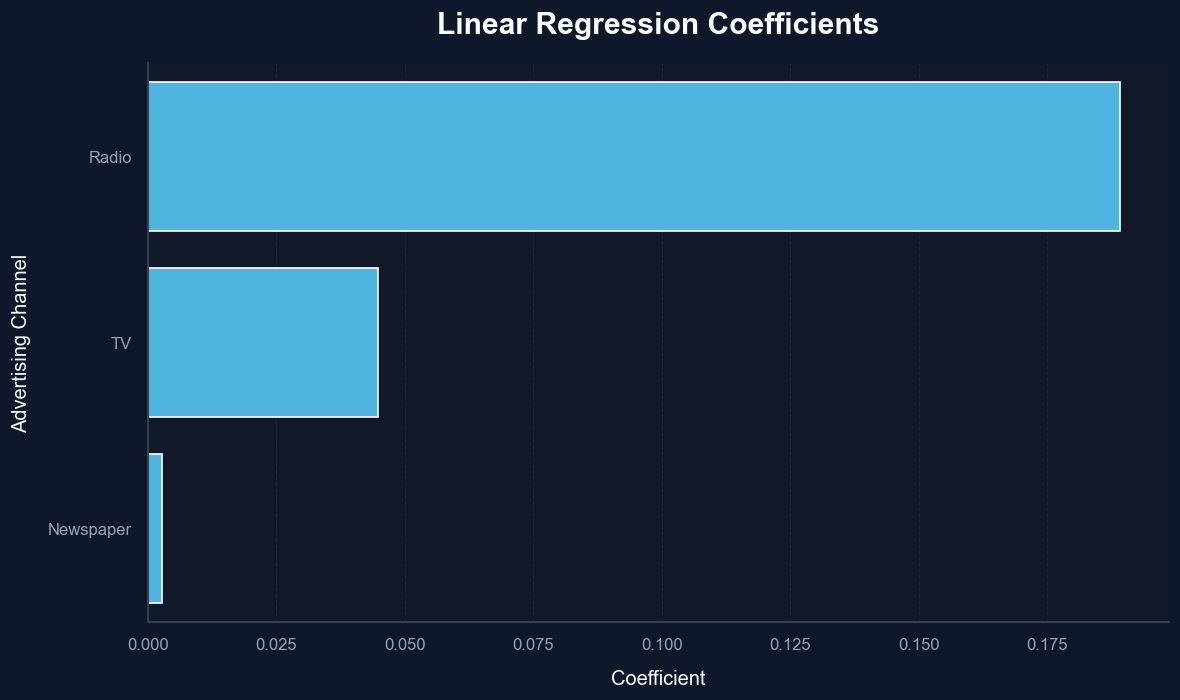

✅ Linear Regression coefficient chart created successfully.
🖼️ Saved as: images/linear_regression_coefficients.png


In [488]:
# ============================================================
# LINEAR REGRESSION COEFFICIENT VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=coefficient_df,
    x="Coefficient",
    y="Feature",
    color=SALES_COLORS["primary"]
)

format_chart(
    title="Linear Regression Coefficients",
    xlabel="Coefficient",
    ylabel="Advertising Channel",
    grid_axis="x"
)

# ------------------------------------------------------------
# Add Zero Reference Line
# ------------------------------------------------------------

plt.axvline(
    x=0,
    color=SALES_COLORS["muted"],
    linestyle="--",
    linewidth=1.2,
    alpha=0.8
)

# ------------------------------------------------------------
# Save Figure
# ------------------------------------------------------------

plt.savefig(
    IMAGES_DIR / "linear_regression_coefficients.png",
    bbox_inches="tight"
)

plt.show()

print("✅ Linear Regression coefficient chart created successfully.")
print("🖼️ Saved as: images/linear_regression_coefficients.png")

## 🔍 Key Observation

The coefficient visualization shows that all advertising channels have
positive coefficients, indicating a positive association with predicted
sales in the Linear Regression model.

The channel with the largest coefficient has the strongest model-based
contribution to predicted sales, while the remaining channels have
comparatively smaller effects.

## 24. Feature Importance — Random Forest

Random Forest provides feature importance scores that estimate the relative contribution of each feature to the model's predictive decisions.

These values can help identify which advertising channels are most useful for predicting Sales within the trained model.

Feature importance should be interpreted as predictive importance rather than proof of causal impact.

In [489]:
# Extract Random Forest feature importance
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
0,TV,0.625447
1,Radio,0.361745
2,Newspaper,0.012808


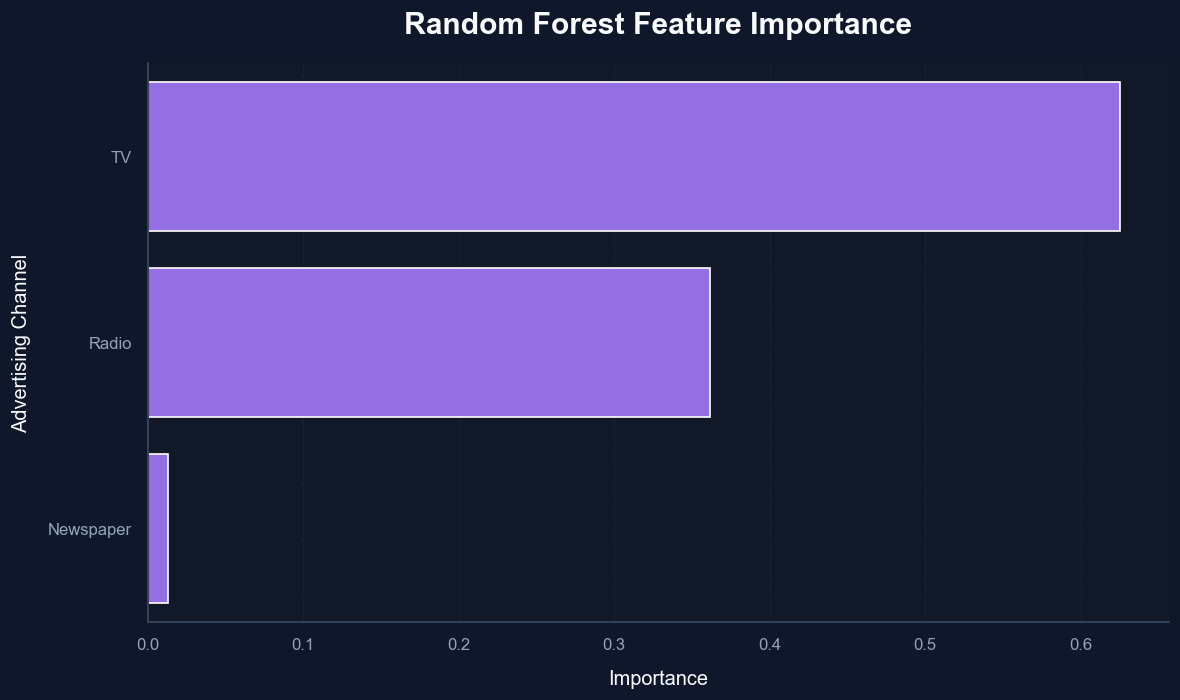

✅ Feature importance chart created successfully.
💾 Image saved as: random_forest_feature_importance.png


In [490]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    color=SALES_COLORS["secondary"]
)

format_chart(
    title="Random Forest Feature Importance",
    xlabel="Importance",
    ylabel="Advertising Channel",
    grid_axis="x"
)

plt.savefig(
    IMAGES_DIR / "random_forest_feature_importance.png",
    bbox_inches="tight",
    facecolor=SALES_COLORS["background"]
)

plt.show()

print("✅ Feature importance chart created successfully.")
print("💾 Image saved as: random_forest_feature_importance.png")

## 🔍 Key Observation

The feature importance analysis identifies the advertising channel that
has the greatest influence on the Random Forest model's sales predictions.

The channel with the highest importance value is the most influential
predictor among the advertising features used in the model.

In [491]:
# Identify the most important advertising channel
most_important_channel = importance_df.iloc[0]["Feature"]
highest_importance = importance_df.iloc[0]["Importance"]

print(
    f"The Random Forest model identifies '{most_important_channel}' "
    f"as the most important feature for predicting Sales."
)

print(
    f"Feature importance: {highest_importance:.4f}"
)

The Random Forest model identifies 'TV' as the most important feature for predicting Sales.
Feature importance: 0.6254


## 25. Sample Sales Prediction

To demonstrate practical usage, the best-performing model is used to predict Sales for a hypothetical advertising budget.

The example uses:

- TV advertising: 200
- Radio advertising: 30
- Newspaper advertising: 40

In [492]:
# Example advertising budget
sample_advertising = pd.DataFrame({
    "TV": [200],
    "Radio": [30],
    "Newspaper": [40]
})

# Generate prediction
sample_prediction = (
    linear_model.predict(sample_advertising)
    if best_model_name == "Linear Regression"
    else random_forest_model.predict(sample_advertising)
)

print(
    f"Predicted Sales using {best_model_name}: "
    f"{sample_prediction[0]:.2f}"
)

Predicted Sales using Random Forest: 18.30


## 26. Final Model Comparison

The following table summarizes the performance of the two regression models.

In [493]:
# Display final model comparison
results_df.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

,Model,MAE,RMSE,R² Score
0,Random Forest,0.613075,0.740335,0.982635
1,Linear Regression,1.460757,1.781600,0.899438


In [494]:
# ------------------------------------------------------------
# 1. Create output directory
# ------------------------------------------------------------

output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

print("Output directory:", output_dir.resolve())


# ------------------------------------------------------------
# 2. Save model comparison results
# ------------------------------------------------------------

results_path = output_dir / "model_comparison.csv"

results_df.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True).to_csv(
    results_path,
    index=False
)

print(f"✓ Model comparison saved: {results_path}")


# ------------------------------------------------------------
# 3. Save Linear Regression coefficients
# ------------------------------------------------------------

coefficients_path = output_dir / "linear_regression_coefficients.csv"

coefficient_df.to_csv(
    coefficients_path,
    index=False
)

print(f"✓ Linear Regression coefficients saved: {coefficients_path}")


# ------------------------------------------------------------
# 4. Save Random Forest feature importance
# ------------------------------------------------------------

importance_path = output_dir / "random_forest_feature_importance.csv"

importance_df.to_csv(
    importance_path,
    index=False
)

print(f"✓ Random Forest feature importance saved: {importance_path}")


# ------------------------------------------------------------
# 5. Save actual vs predicted test results
# ------------------------------------------------------------

prediction_output = pd.DataFrame({
    "Actual_Sales": y_test.values,
    "Predicted_Sales": best_predictions,
    "Residual": residuals.values
})

prediction_path = output_dir / "actual_vs_predicted_sales.csv"

prediction_output.to_csv(
    prediction_path,
    index=False
)

print(f"✓ Actual vs predicted results saved: {prediction_path}")


# ------------------------------------------------------------
# 6. Save final model summary
# ------------------------------------------------------------

best_model_metrics = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

final_summary = pd.DataFrame({
    "Metric": [
        "Best Model",
        "MAE",
        "RMSE",
        "R² Score",
        "Most Important Advertising Channel",
        "Feature Importance"
    ],
    "Value": [
        best_model_name,
        round(best_model_metrics["MAE"], 4),
        round(best_model_metrics["RMSE"], 4),
        round(best_model_metrics["R² Score"], 4),
        most_important_channel,
        round(highest_importance, 4)
    ]
})

summary_path = output_dir / "final_model_summary.csv"

final_summary.to_csv(
    summary_path,
    index=False
)

print(f"✓ Final model summary saved: {summary_path}")


# ------------------------------------------------------------
# 7. Save sample prediction
# ------------------------------------------------------------

sample_output = pd.DataFrame({
    "TV": sample_advertising["TV"],
    "Radio": sample_advertising["Radio"],
    "Newspaper": sample_advertising["Newspaper"],
    "Predicted_Sales": sample_prediction
})

sample_path = output_dir / "sample_sales_prediction.csv"

sample_output.to_csv(
    sample_path,
    index=False
)

print(f"✓ Sample prediction saved: {sample_path}")


# ------------------------------------------------------------
# 8. Display final output files
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL OUTPUT FILES")
print("=" * 60)

for file in sorted(output_dir.iterdir()):
    if file.is_file():
        print(f"✓ {file.name}")

print("=" * 60)
print("All Task 5 output files have been saved successfully.")
print("=" * 60)

Output directory: C:\Users\USER\PycharmProjects\OIBSIP\OIBSIP\DataScience-Task5-SalesPrediction\outputs
✓ Model comparison saved: ..\outputs\model_comparison.csv
✓ Linear Regression coefficients saved: ..\outputs\linear_regression_coefficients.csv
✓ Random Forest feature importance saved: ..\outputs\random_forest_feature_importance.csv
✓ Actual vs predicted results saved: ..\outputs\actual_vs_predicted_sales.csv
✓ Final model summary saved: ..\outputs\final_model_summary.csv
✓ Sample prediction saved: ..\outputs\sample_sales_prediction.csv

FINAL OUTPUT FILES
✓ actual_vs_predicted_sales.csv
✓ final_model_summary.csv
✓ linear_regression_coefficients.csv
✓ model_comparison.csv
✓ random_forest_feature_importance.csv
✓ sample_sales_prediction.csv
All Task 5 output files have been saved successfully.


## 27. Final Conclusion

This project developed a machine learning regression system for predicting product Sales using advertising expenditure across TV, Radio, and Newspaper channels.

The analysis included exploratory data analysis, statistical summaries, pairwise visualization, correlation analysis, model training, model evaluation, residual analysis, and feature importance.

Two regression models were trained and evaluated using MAE, RMSE, and R² Score.

The best-performing model was selected based on its performance on the unseen test dataset.

The feature importance analysis was also used to identify the advertising channel with the strongest predictive contribution.

### Key Findings

- The relationship between advertising expenditure and Sales was explored through multiple visualizations.
- Linear Regression provided an interpretable baseline model.
- Random Forest was evaluated as a nonlinear ensemble alternative.
- Model performance was compared using MAE, RMSE, and R².
- Residual analysis was performed to inspect prediction errors.
- Advertising channel importance was analyzed using model coefficients and Random Forest feature importance.

### Business Insight

The advertising channel identified as most important by the trained model may deserve further investigation when making future advertising decisions. However, feature importance and correlation represent predictive relationships and should not be interpreted as proof of causation.

### Future Improvements

- Hyperparameter tuning
- K-fold cross-validation
- Additional regression algorithms
- Feature scaling where appropriate
- Larger and more recent advertising datasets
- Cost/ROI analysis for individual advertising channels
- Model deployment as an interactive application